# Skin Disease Detection v3 - EfficientNetB0
## 11 classes | 3-phase training | Grad-CAM



## Cell 1 — Mount Drive + kiểm tra GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus)
if not gpus:
    print('CẢNH BÁO: Không có GPU! Vào Runtime > Change runtime type > T4 GPU')

Mounted at /content/drive
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 - Cài thư viện + imports

In [2]:
!pip install albumentations opencv-python-headless -q

import os, json, glob, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
import albumentations as A
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
print('Imports OK')

Imports OK


## Cell 3 - Cấu hình

In [3]:
DRIVE_DATA_DIR = '/content/drive/MyDrive/Skin Disease Detection/skin_data'
MODEL_DIR      = '/content/drive/MyDrive/Skin Disease Detection/skin_model_v3'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE             = (224, 224)
BATCH_SIZE           = 32
NUM_EPOCHS_FROZEN    = 20
NUM_EPOCHS_FINETUNE  = 15
NUM_EPOCHS_FINETUNE2 = 20
CONFIDENCE_THRESHOLD = 0.60

with open(os.path.join(DRIVE_DATA_DIR, 'class_names.json')) as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Model dir: {MODEL_DIR}')

Classes (11): ['acne_rosacea', 'alopecia', 'atopic_dermatitis', 'bullous_disease', 'drug_eruptions', 'eczema', 'nail_fungus', 'scabies', 'tinea', 'urticaria', 'warts']
Model dir: /content/drive/MyDrive/Skin Disease Detection/skin_model_v3


## Cell 4 - Copy data về local
Tiết kiệm thời gian cho mỗi epoch


In [4]:
LOCAL_DIR = '/content/skin_data'

if not os.path.exists(LOCAL_DIR):
    print('Đang copy data từ Drive về Colab local...')
    print('(Mất khoảng 8–10 phút, chỉ cần làm 1 lần/session)')
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DIR)
    print('Copy xong!')
else:
    print('Data đã có local rồi, bỏ qua copy.')

DATA_DIR  = LOCAL_DIR
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')
print(f'DATA_DIR = {DATA_DIR}')

for split in ['train', 'val', 'test']:
    path = os.path.join(DATA_DIR, split)
    n_classes = len(os.listdir(path))
    print(f'  {split}: {n_classes} classes')

Đang copy data từ Drive về Colab local...
(Mất khoảng 8–10 phút, chỉ cần làm 1 lần/session)
Copy xong!
DATA_DIR = /content/skin_data
  train: 11 classes
  val: 11 classes
  test: 11 classes


## Cell 5 - Load data + Augmentation

EfficientNetB0 có preprocessing layer tích hợp, nhận ảnh 0–255.

HueSaturation + RGBShift giúp model
generalize tốt hơn trên da vàng/da tối.

In [5]:
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=0, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=30, val_shift_limit=20, p=0.7),
    A.RGBShift(r_shift_limit=15, g_shift_limit=10, b_shift_limit=5, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    A.ToGray(p=0.05),
    A.GaussNoise(var_limit=(5, 20), p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
])

class SkinDataset(Sequence):
    def __init__(self, directory, img_size, batch_size, class_names, aug=None, shuffle=True):
        self.img_size    = img_size
        self.batch_size  = batch_size
        self.class_names = class_names
        self.num_classes = len(class_names)
        self.aug         = aug
        self.shuffle     = shuffle
        self.paths, self.labels = [], []
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(directory, cls)
            if not os.path.exists(cls_dir):
                print(f'  CẢNH BÁO: không tìm thấy {cls_dir}')
                continue
            for ext in ('*.jpg','*.jpeg','*.png','*.bmp','*.webp'):
                for fp in glob.glob(os.path.join(cls_dir, ext)):
                    self.paths.append(fp)
                    self.labels.append(idx)
        self.indices = list(range(len(self.paths)))
        if shuffle: random.shuffle(self.indices)
        self.samples = len(self.paths)
        self.classes = np.array(self.labels)
        print(f'  {os.path.basename(directory)}: {self.samples} ảnh, {self.num_classes} classes')

    def __len__(self):
        return int(np.ceil(self.samples / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        Y = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)
        for i, bi in enumerate(batch_idx):
            img = np.array(Image.open(self.paths[bi]).convert('RGB').resize(self.img_size))
            if self.aug:
                img = self.aug(image=img)['image']

            X[i] = img.astype(np.float32)
            Y[i, self.labels[bi]] = 1.0
        return X, Y

    def on_epoch_end(self):
        if self.shuffle: random.shuffle(self.indices)

random.seed(42)
np.random.seed(42)

print('Đang load data...')
train_gen = SkinDataset(TRAIN_DIR, IMG_SIZE, BATCH_SIZE, CLASS_NAMES, aug=aug_pipeline, shuffle=True)
val_gen   = SkinDataset(VAL_DIR,   IMG_SIZE, BATCH_SIZE, CLASS_NAMES, aug=None, shuffle=False)
test_gen  = SkinDataset(TEST_DIR,  IMG_SIZE, BATCH_SIZE, CLASS_NAMES, aug=None, shuffle=False)

print(f'\nTổng: train={train_gen.samples}, val={val_gen.samples}, test={test_gen.samples}')

bx, _ = train_gen[0]
print(f'Pixel range: min={bx.min():.1f}, max={bx.max():.1f}')


Đang load data...
  train: 6639 ảnh, 11 classes
  val: 1418 ảnh, 11 classes
  test: 1436 ảnh, 11 classes

Tổng: train=6639, val=1418, test=1436


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_2681/3459121298.py:9: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.2),


Pixel range: min=0.0, max=255.0
Kỳ vọng: min~0, max~255 (KHÔNG phải 0–1)


## Cell 6 - Class weights

In [6]:
labels  = train_gen.classes
cw_arr  = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(cw_arr))

print('Class weights:')
for idx, name in enumerate(CLASS_NAMES):
    bar = '█' * int(cw_arr[idx] * 10)
    print(f'  {name:<30s} {cw_arr[idx]:.3f}  {bar}')

Class weights:
  acne_rosacea                   0.978  █████████
  alopecia                       2.888  ████████████████████████████
  atopic_dermatitis              1.410  ██████████████
  bullous_disease                1.540  ███████████████
  drug_eruptions                 1.710  █████████████████
  eczema                         0.559  █████
  nail_fungus                    0.663  ██████
  scabies                        1.601  ████████████████
  tinea                          0.530  █████
  urticaria                      3.262  ████████████████████████████████
  warts                          0.635  ██████


## Cell 7 - Build model
```
Input (224×224×3, float32, range 0-255)
  - EfficientNetB0 preprocessing  
  - EfficientNetB0 backbone       (frozen ở phase 1)
  - GlobalAveragePooling2D        (7×7×1280 → 1280)
  - BatchNormalization
  - Dropout(0.4)
  - Dense(256, relu)
  - Dropout(0.3)
  - Dense(11, softmax)            (11 classes)
```

In [7]:
def build_model(num_classes, trainable_base=False):
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = trainable_base
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(base.input, out), base

model, base_model = build_model(NUM_CLASSES, trainable_base=False)

total   = len(model.layers)
trained = sum(1 for l in model.layers if l.trainable)
print(f'Tổng layers  : {total}')
print(f'Trainable    : {trained}  (custom head)')
print(f'Frozen       : {total-trained}  (EfficientNetB0 base)')
print(f'Input shape  : {model.input_shape}')
print(f'Output shape : {model.output_shape}  ← phải là (None, {NUM_CLASSES})')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tổng layers  : 244
Trainable    : 6  (custom head)
Frozen       : 238  (EfficientNetB0 base)
Input shape  : (None, 224, 224, 3)
Output shape : (None, 11)  ← phải là (None, 11)


## Cell 8 - Phase 1: Train custom head (base frozen)

Chỉ train 6 layer custom head, base EfficientNetB0 đóng băng.



In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(MODEL_DIR,'best_phase1.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

print('=== Phase 1: Base frozen ===')
history1 = model.fit(
    train_gen, epochs=NUM_EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=cb1, verbose=1
)
print(f'\nPhase 1 best val_accuracy: {max(history1.history["val_accuracy"]):.4f}')

=== Phase 1: Base frozen ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.2334 - loss: 2.8579
Epoch 1: val_accuracy improved from None to 0.48872, saving model to /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/best_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/best_phase1.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 170s 652ms/step - accuracy: 0.2773 - loss: 2.6153 - val_accuracy: 0.4887 - val_loss: 1.5879 - learning_rate: 0.0010
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.3294 - loss: 2.1620
Epoch 2: val_accuracy did not improve from 0.48872
208/208 ━━━━━━━━━━━━━━━━━━━━ 91s 435ms/step - accuracy: 0.3382 - loss: 2.1379 - val_accuracy: 0.4781 - val_loss: 1.5563 - learning_rate: 0.0010
Epoch 3/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.3541 - loss: 1.9484
Epoch 3: val_accuracy improved from 0.48872 to 0.49224, saving model to /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/best

## Cell 9 - Phase 2: Fine-tune lr=1e-5 (BN frozen)

Unfreeze toàn bộ base nhưng freeze lại tất cả BN layers.

BN lưu statistics của ImageNet - nếu train lại sẽ mất kiến thức pretrained.

Learning rate 1e-5 - nhỏ để không phá weights ImageNet.

In [9]:
# Unfreeze toàn bộ
for layer in model.layers:
    layer.trainable = True

# Freeze lại tất cả BN layers
bn_frozen = 0
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        bn_frozen += 1

print(f'BN frozen: {bn_frozen}')
print(f'Trainable: {sum(1 for l in model.layers if l.trainable)}')

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(MODEL_DIR,'best_phase2.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
]

print('\n=== Phase 2: Fine-tune lr=1e-5 ===')
history2 = model.fit(
    train_gen, epochs=NUM_EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=cb2, verbose=1
)
print(f'\nPhase 2 best val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

BN frozen: 50
Trainable: 194

=== Phase 2: Fine-tune lr=1e-5 ===
Epoch 1/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.5051 - loss: 1.3704
Epoch 1: val_accuracy improved from None to 0.59168, saving model to /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/best_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/best_phase2.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 196s 661ms/step - accuracy: 0.5050 - loss: 1.3617 - val_accuracy: 0.5917 - val_loss: 1.2466 - learning_rate: 1.0000e-05
Epoch 2/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.5052 - loss: 1.3246
Epoch 2: val_accuracy did not improve from 0.59168
208/208 ━━━━━━━━━━━━━━━━━━━━ 98s 470ms/step - accuracy: 0.5075 - loss: 1.3227 - val_accuracy: 0.5860 - val_loss: 1.2488 - learning_rate: 1.0000e-05
Epoch 3/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5204 - loss: 1.2909
Epoch 3: val_accuracy improved from 0.59168 to 0.59520, saving 

## Cell 10 - Phase 3: Fine-tune lr=1e-4 (BN frozen)

Phase 2 với lr=1e-5 tiến chậm và bị stuck

Phase 3 với lr=1e-4 giúp model
thoát khỏi local minimum.

BN vẫn tiếp tục frozen.

In [10]:
# BN vẫn frozen từ phase 2, chỉ cần recompile với lr mới
for layer in model.layers:
    layer.trainable = True
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb3 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(MODEL_DIR,'best_final.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
]

print('=== Phase 3: Fine-tune lr=1e-4 ===')
history3 = model.fit(
    train_gen, epochs=NUM_EPOCHS_FINETUNE2,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=cb3, verbose=1
)
print(f'\nPhase 3 best val_accuracy: {max(history3.history["val_accuracy"]):.4f}')

=== Phase 3: Fine-tune lr=1e-4 ===
Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.5135 - loss: 1.2955
Epoch 1: val_accuracy improved from None to 0.60649, saving model to /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/best_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/best_final.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 178s 620ms/step - accuracy: 0.5070 - loss: 1.3074 - val_accuracy: 0.6065 - val_loss: 1.2186 - learning_rate: 1.0000e-04
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.5392 - loss: 1.2395
Epoch 2: val_accuracy did not improve from 0.60649
208/208 ━━━━━━━━━━━━━━━━━━━━ 89s 426ms/step - accuracy: 0.5335 - loss: 1.2321 - val_accuracy: 0.6008 - val_loss: 1.1781 - learning_rate: 1.0000e-04
Epoch 3/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.5535 - loss: 1.1937
Epoch 3: val_accuracy improved from 0.60649 to 0.61001, saving model to /content/drive/MyDrive/

## Cell 11 - Plot training curves

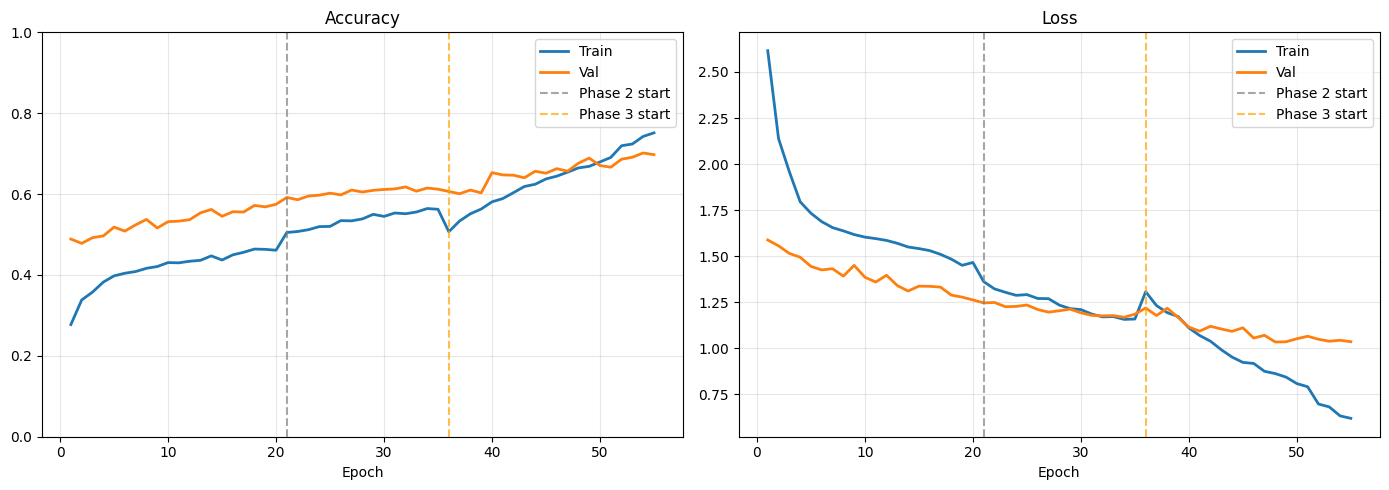

Saved training_curve.png


In [11]:
acc      = history1.history['accuracy']     + history2.history['accuracy']     + history3.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']         + history3.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']     + history3.history['val_loss']
epochs_x = range(1, len(acc) + 1)
p2_start = len(history1.history['accuracy']) + 1
p3_start = p2_start + len(history2.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_x, acc,     label='Train', linewidth=2)
ax1.plot(epochs_x, val_acc, label='Val',   linewidth=2)
ax1.axvline(p2_start, color='gray',  linestyle='--', alpha=0.7, label='Phase 2 start')
ax1.axvline(p3_start, color='orange',linestyle='--', alpha=0.7, label='Phase 3 start')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_ylim([0, 1])

ax2.plot(epochs_x, loss,     label='Train', linewidth=2)
ax2.plot(epochs_x, val_loss, label='Val',   linewidth=2)
ax2.axvline(p2_start, color='gray',  linestyle='--', alpha=0.7, label='Phase 2 start')
ax2.axvline(p3_start, color='orange',linestyle='--', alpha=0.7, label='Phase 3 start')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_curve.png'), dpi=150)
plt.show()
print('Saved training_curve.png')

## Cell 12 - Evaluate trên test set

In [12]:
best_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, 'best_final.keras'))

print('Đang predict test set...')
y_pred_prob = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes[:len(y_pred)]

test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
print(f'\n{"="*50}')
print(f'Test accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'Test loss     : {test_loss:.4f}')
print(f'{"="*50}\n')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Đang predict test set...
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 573ms/step

Test accuracy : 0.7117 (71.2%)
Test loss     : 1.0661

                   precision    recall  f1-score   support

     acne_rosacea       0.75      0.88      0.81       133
         alopecia       0.65      0.93      0.77        46
atopic_dermatitis       0.58      0.63      0.61        93
  bullous_disease       0.54      0.68      0.60        85
   drug_eruptions       0.54      0.58      0.56        77
           eczema       0.71      0.69      0.70       233
      nail_fungus       0.95      0.81      0.87       196
          scabies       0.57      0.62      0.59        82
            tinea       0.79      0.63      0.70       245
        urticaria       0.62      0.80      0.70        41
            warts       0.74      0.69      0.72       205

         accuracy                           0.71      1436
        macro avg       0.68      0.72      0.69      1436
     weighted avg       0.73      0.71      0.71 

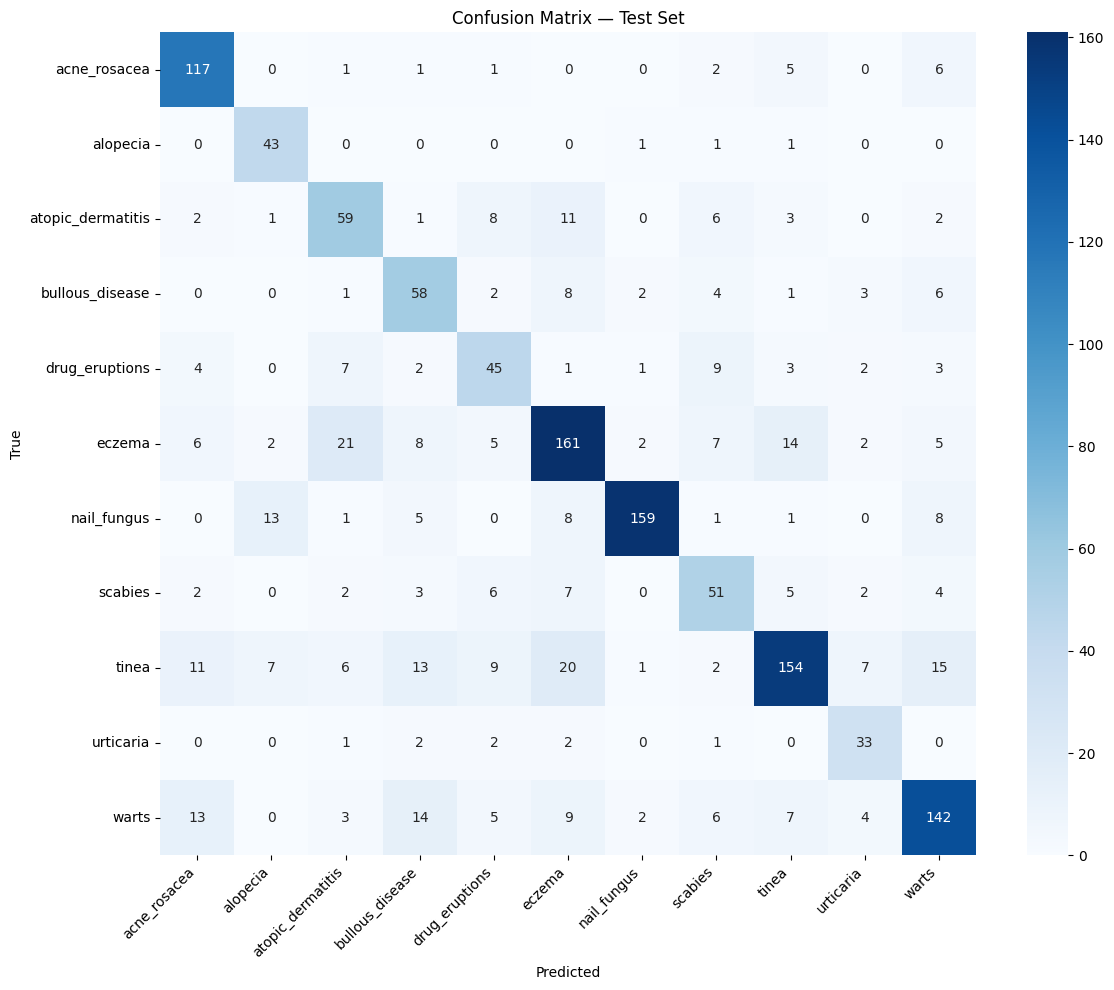

In [13]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## Cell 13 - Grad-CAM

Visualize vùng da mà model tập trung khi chẩn đoán.
- Đỏ/vàng = model chú ý nhiều
- Xanh/tím = model ít chú ý

Nếu heatmap tập trung vào vùng tổn thương --> model học đúng.

Nếu tập trung vào nền ảnh --> model học shortcut.

In [14]:
def compute_gradcam(model, img_array, class_idx=None):
    last_conv = model.get_layer('top_conv')
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[last_conv.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        class_score = predictions[:, class_idx]
    grads   = tape.gradient(class_score, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = tf.reduce_sum(conv_outputs[0] * weights, axis=-1)
    cam     = tf.nn.relu(cam).numpy()
    cam     = cv2.resize(cam, (224, 224))
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def overlay_gradcam(original_img, cam, alpha=0.4):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = heatmap * alpha + original_img * (1 - alpha)
    return np.uint8(np.clip(overlay, 0, 255))

def predict_and_gradcam(img_path, model, class_names, threshold=0.60):
    original  = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    img_input = np.expand_dims(original.astype(np.float32), axis=0)
    preds     = model.predict(img_input, verbose=0)[0]
    top_idx   = np.argmax(preds)
    top_conf  = preds[top_idx]
    top_name  = class_names[top_idx]

    print(f'Dự đoán: {top_name} ({top_conf*100:.1f}%)')
    if top_conf < threshold:
        print(f'  Confidence thấp ({top_conf*100:.1f}% < {threshold*100:.0f}%) — kết quả không đáng tin')

    print('\nTop-3:')
    for i in np.argsort(preds)[::-1][:3]:
        print(f'  {class_names[i]:<30s}: {preds[i]*100:.1f}%')

    cam         = compute_gradcam(model, img_input, class_idx=top_idx)
    cam_overlay = overlay_gradcam(original, cam)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(original);      axes[0].set_title('Ảnh gốc');          axes[0].axis('off')
    axes[1].imshow(cam_overlay);   axes[1].set_title(f'Grad-CAM\n{top_name} ({top_conf*100:.1f}%)'); axes[1].axis('off')
    im = axes[2].imshow(cam, cmap='jet', vmin=0, vmax=1)
    axes[2].set_title('Heatmap thuần'); axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.suptitle(f'Grad-CAM — {top_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'gradcam_sample.png'), dpi=150)
    plt.show()
    return preds, cam

print('Grad-CAM ready.')
print('Dùng: predict_and_gradcam(\'path/to/image.jpg\', best_model, CLASS_NAMES)')

Grad-CAM ready.
Dùng: predict_and_gradcam('path/to/image.jpg', best_model, CLASS_NAMES)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


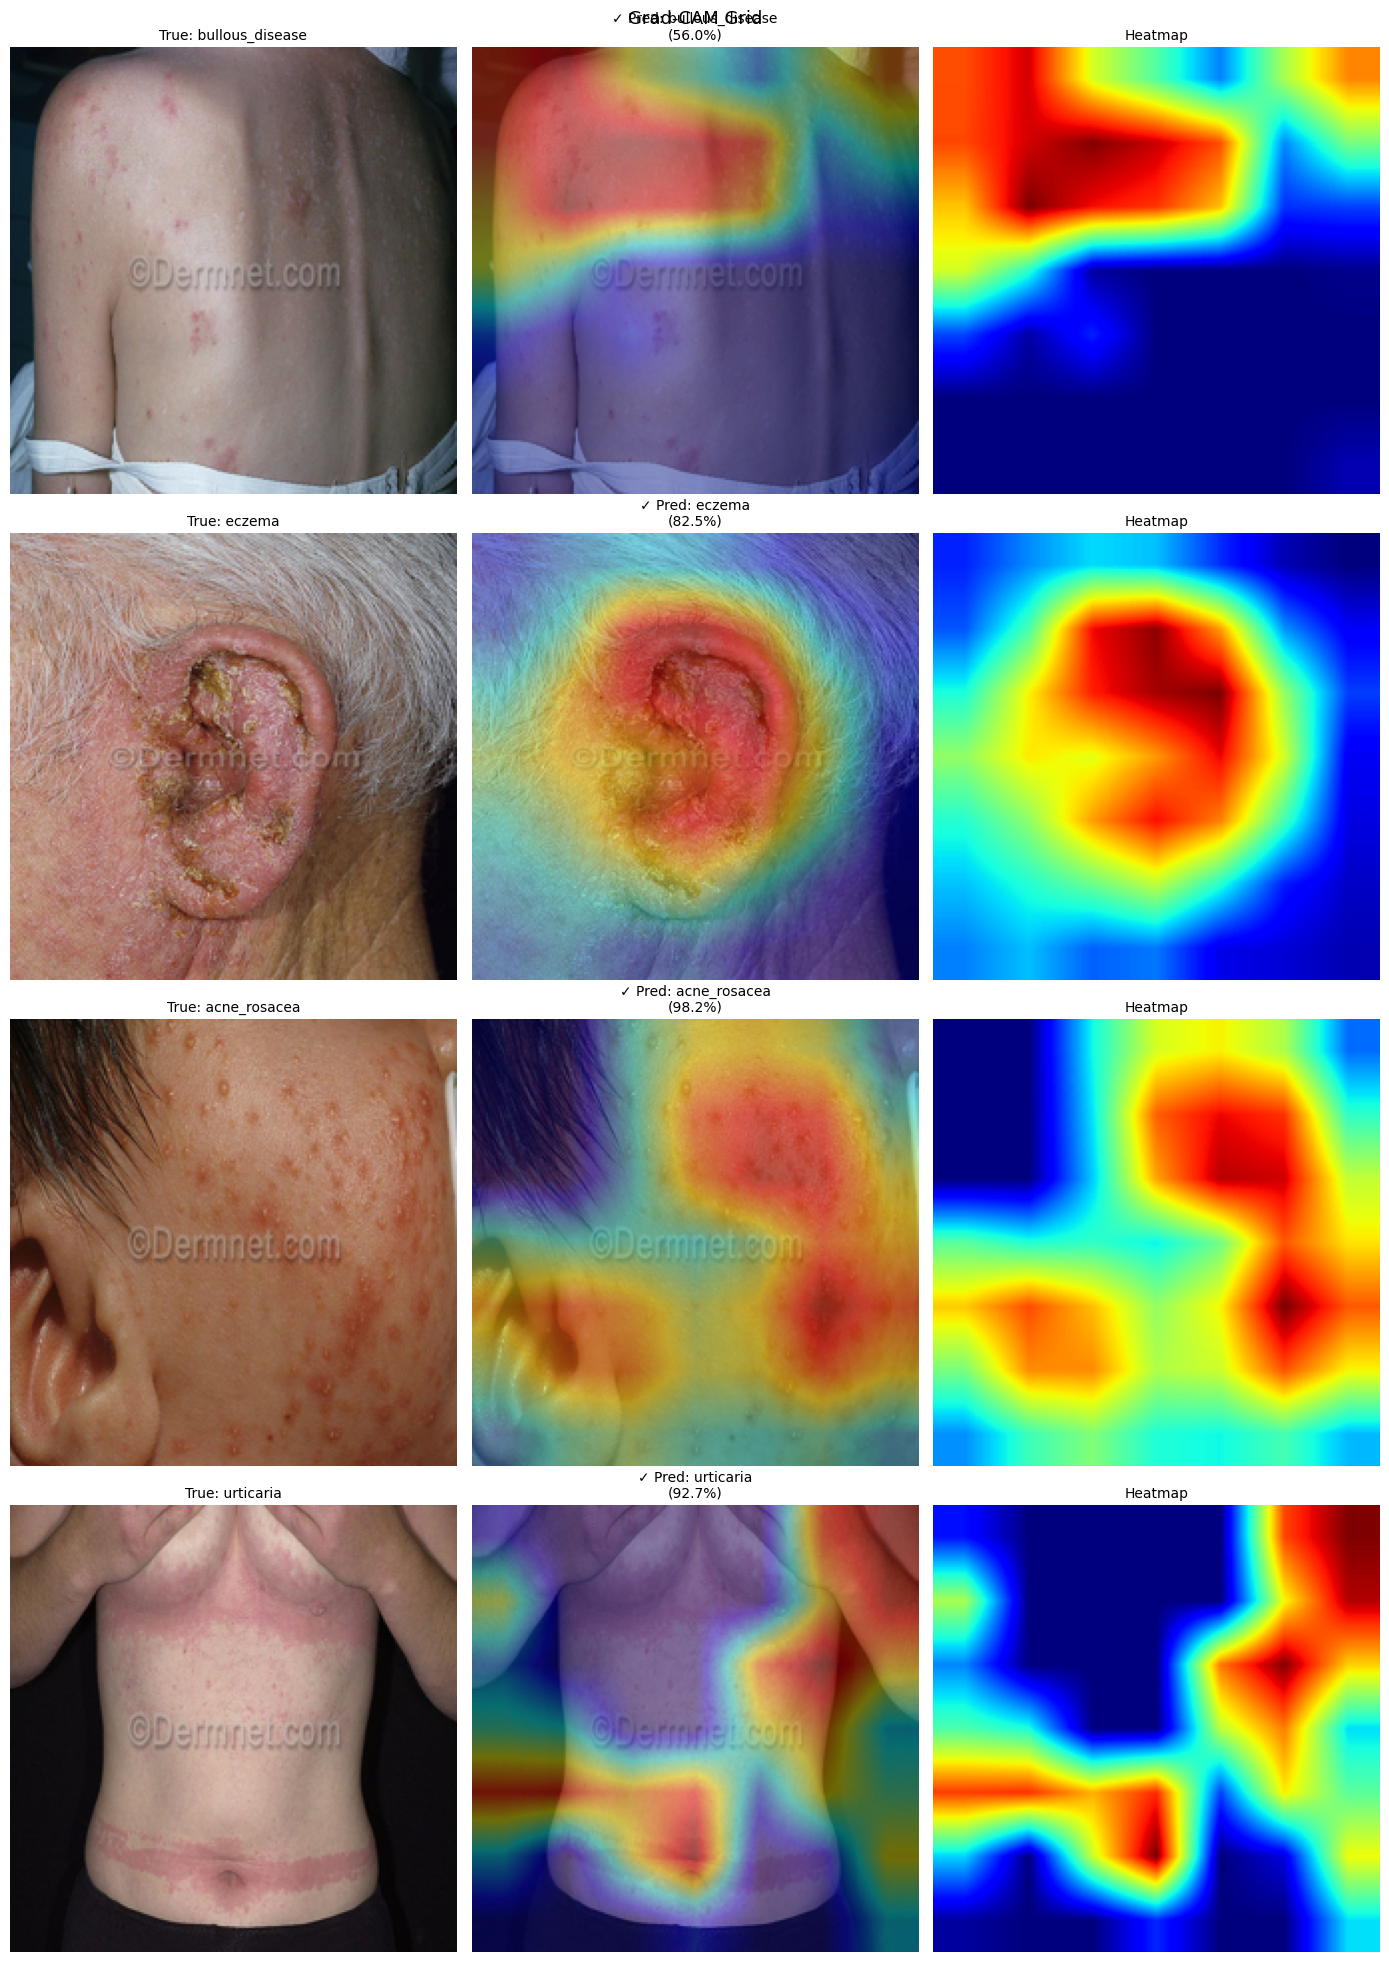

In [15]:

sample_classes = random.sample(CLASS_NAMES, min(4, NUM_CLASSES))
fig, axes = plt.subplots(len(sample_classes), 3, figsize=(14, 5*len(sample_classes)))

for row, cls in enumerate(sample_classes):
    imgs = glob.glob(os.path.join(TEST_DIR, cls, '*.jpg')) + \
           glob.glob(os.path.join(TEST_DIR, cls, '*.png'))
    if not imgs: continue
    img_path  = random.choice(imgs[:10])
    original  = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    img_input = np.expand_dims(original.astype(np.float32), axis=0)
    preds     = best_model.predict(img_input, verbose=0)[0]
    pred_idx  = np.argmax(preds)
    pred_name = CLASS_NAMES[pred_idx]
    conf      = preds[pred_idx]
    cam         = compute_gradcam(best_model, img_input, class_idx=pred_idx)
    cam_overlay = overlay_gradcam(original, cam)
    correct = '✓' if pred_name == cls else '✗'
    axes[row,0].imshow(original);     axes[row,0].set_title(f'True: {cls}', fontsize=10);                           axes[row,0].axis('off')
    axes[row,1].imshow(cam_overlay);  axes[row,1].set_title(f'{correct} Pred: {pred_name}\n({conf*100:.1f}%)', fontsize=10); axes[row,1].axis('off')
    axes[row,2].imshow(cam, cmap='jet'); axes[row,2].set_title('Heatmap', fontsize=10); axes[row,2].axis('off')

plt.suptitle('Grad-CAM Grid', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'gradcam_grid.png'), dpi=150)
plt.show()

## Cell 14 - Lưu model

In [16]:
model_path = os.path.join(MODEL_DIR, 'skin_disease_model_v3.keras')
best_model.save(model_path)
size_mb = os.path.getsize(model_path) / 1024 / 1024
print(f'Model saved: {model_path} ({size_mb:.1f} MB)')

cn_path = os.path.join(MODEL_DIR, 'class_names.json')
with open(cn_path, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print(f'class_names.json: {cn_path}')

p1_best = max(history1.history['val_accuracy'])
p2_best = max(history2.history['val_accuracy'])
p3_best = max(history3.history['val_accuracy'])
config = {
    'version'             : 'v3',
    'model'               : 'EfficientNetB0',
    'num_classes'         : NUM_CLASSES,
    'class_names'         : CLASS_NAMES,
    'removed_classes'     : ['psoriasis', 'cellulitis', 'contact_dermatitis'],
    'phase1_val_accuracy' : round(p1_best, 4),
    'phase2_val_accuracy' : round(p2_best, 4),
    'phase3_val_accuracy' : round(p3_best, 4),
    'test_accuracy'       : round(float(test_acc), 4),
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'bugs_fixed'          : [
        'No rescale=1/255 - EfficientNetB0 expects 0-255',
        'BatchNormalization frozen in phase 2 and 3',
        'base_model fix when loading checkpoint'
    ]
}
cfg_path = os.path.join(MODEL_DIR, 'training_config.json')
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(f'Config saved: {cfg_path}')

print(f'\n=== KẾT QUẢ TỔNG KẾT ===')
print(f'Phase 1 best val_accuracy : {p1_best*100:.1f}%')
print(f'Phase 2 best val_accuracy : {p2_best*100:.1f}%')
print(f'Phase 3 best val_accuracy : {p3_best*100:.1f}%')
print(f'Test accuracy             : {test_acc*100:.1f}%')
print(f'\nDownload về máy:')
print(f'  {model_path}')
print(f'  {cn_path}')

Model saved: /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/skin_disease_model_v3.keras (50.4 MB)
class_names.json: /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/class_names.json
Config saved: /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/training_config.json

=== KẾT QUẢ TỔNG KẾT ===
Phase 1 best val_accuracy : 57.5%
Phase 2 best val_accuracy : 61.8%
Phase 3 best val_accuracy : 70.2%
Test accuracy             : 71.2%

Download về máy:
  /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/skin_disease_model_v3.keras
  /content/drive/MyDrive/Skin Disease Detection/skin_model_v3/class_names.json


## Cell 15 - Test 1 ảnh bất kỳ

Test ảnh: /content/skin_data/test/acne_rosacea/acne_rosacea_00089.jpg
Dự đoán: acne_rosacea (82.6%)

Top-3:
  acne_rosacea                  : 82.6%
  warts                         : 16.1%
  eczema                        : 1.0%


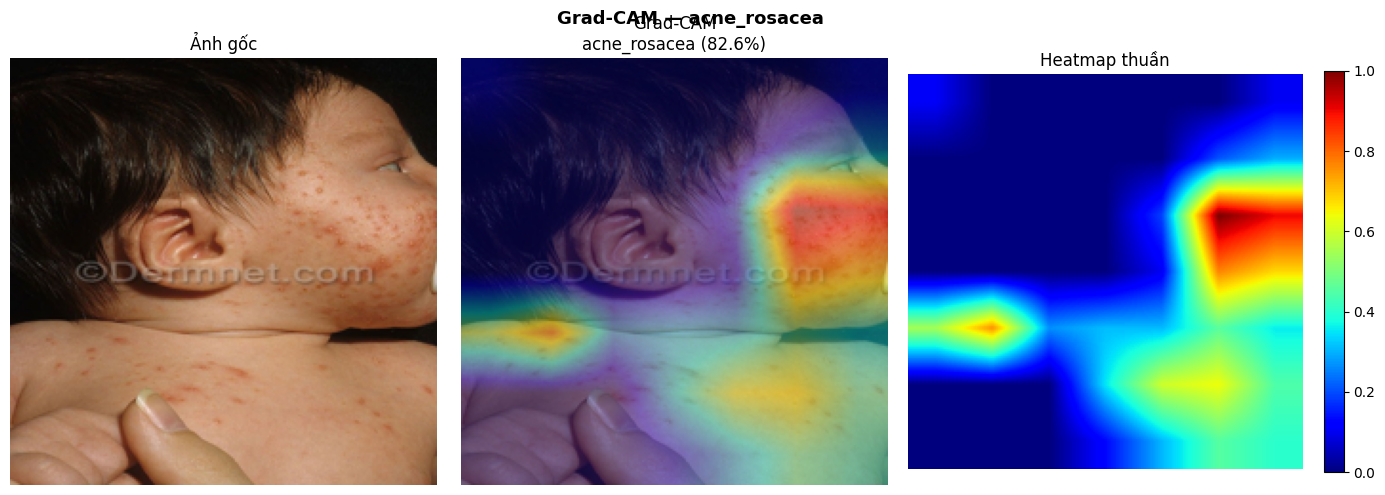

In [17]:

all_test_imgs = glob.glob(os.path.join(TEST_DIR, '*', '*.jpg'))
if all_test_imgs:
    test_img = random.choice(all_test_imgs)
    print(f'Test ảnh: {test_img}')
    predict_and_gradcam(test_img, best_model, CLASS_NAMES, threshold=CONFIDENCE_THRESHOLD)
else:
    print('Không tìm thấy ảnh test.')